# Librerias y carga del dataset

In [68]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import stats

In [69]:
df = pd.read_csv('telecom_customer_churn_feature_engineering.csv')
df.head()

,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
0,10001,2019-01-01,65,Male,Multan,Bachelor,Employed,57643.0,10049.0,5.8,52.0,6-Month,1,Coverage is poor in my location,0
1,10002,2019-01-02,22,Female,Peshawar,Master,Employed,18207.0,2752.0,11.9,22.0,6-Month,2,Billing issues occurred multiple times,0
2,10003,2019-01-03,43,Male,Gujranwala,Secondary,Employed,13075.0,3155.0,40.0,87.0,Monthly,0,Billing issues occurred multiple times,0
3,10004,2019-01-04,21,Male,Lahore,Secondary,Employed,38890.0,5859.0,8.5,147.0,6-Month,2,Customer support was helpful,0
4,10005,2019-01-05,37,Female,Hyderabad,Primary,Employed,17475.0,5106.0,3.3,183.0,12-Month,0,Coverage is poor in my location,0


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1200 non-null   int64  
 1   signup_date        1200 non-null   str    
 2   age                1200 non-null   int64  
 3   gender             1200 non-null   str    
 4   city               1200 non-null   str    
 5   education_level    1200 non-null   str    
 6   employment_status  1200 non-null   str    
 7   monthly_income     1200 non-null   float64
 8   monthly_bill       1200 non-null   float64
 9   internet_usage_gb  1200 non-null   float64
 10  call_minutes       1200 non-null   float64
 11  contract_type      1200 non-null   str    
 12  support_tickets    1200 non-null   int64  
 13  customer_feedback  1200 non-null   str    
 14  churn              1200 non-null   int64  
dtypes: float64(4), int64(4), str(7)
memory usage: 140.8 KB


Content

The dataset consists of customer records with the following columns:

    customer_id: A unique identifier for each customer.
    signup_date: The date when the customer signed up for the telecom service.
    age: The age of the customer.
    gender: The gender of the customer.
    city: The city where the customer resides.
    education_level: The customer's highest level of education.
    employment_status: The employment status of the customer.
    monthly_income: The customer's estimated monthly income.
    monthly_bill: The total monthly bill amount for the customer.
    internet_usage_gb: The customer's monthly internet usage in gigabytes.
    call_minutes: The total number of call minutes used by the customer in a month.
    contract_type: The type of contract the customer has (e.g., Monthly, 6-Month, 12-Month).
    support_tickets: The number of customer support tickets raised by the customer.
    customer_feedback: Textual feedback provided by the customer.
    churn: A binary indicator (1 or 0) denoting whether the customer has churned (left the service).



In [71]:
df.shape

(1200, 15)

# Funciones 

In [72]:
def boxplot (df,columna, nombre,categoria = None):
    sns.boxplot(data = df, x= columna,hue =categoria)
    plt.title(f'Boxplot de {nombre}')

    return plt.show()

def histograma (df,columna,nombre):
    sns.histplot(data = df, x = columna)
    plt.title(f'Histograma de {nombre}')

    return plt.show()


In [73]:
def borrar_outliers(df,columna):
    # Detecta cuántos outliers hay
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1 #rango intercuartilico

    #halla outliers
    outliers = df[(df[columna] < Q1 - 1.5*IQR) | (df[columna] > Q3 + 1.5*IQR)] #limite superior e inferior
    print(f"Outliers encontrados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

    #filtra el dataset sin esos outliers
    condicion = (df[columna] >= Q1 - 1.5*IQR) & (df[columna] <= Q3 + 1.5*IQR)
    df= df[condicion]


    return df

In [74]:
def cohens_d(g1, g2):
    pooled_std = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    return (g1.mean() - g2.mean()) / pooled_std

# Exploracion 

### Edad

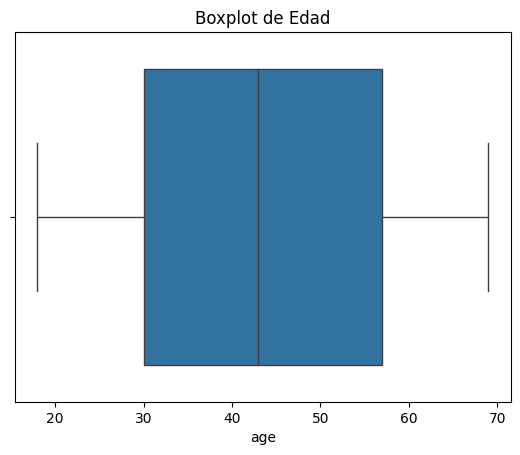

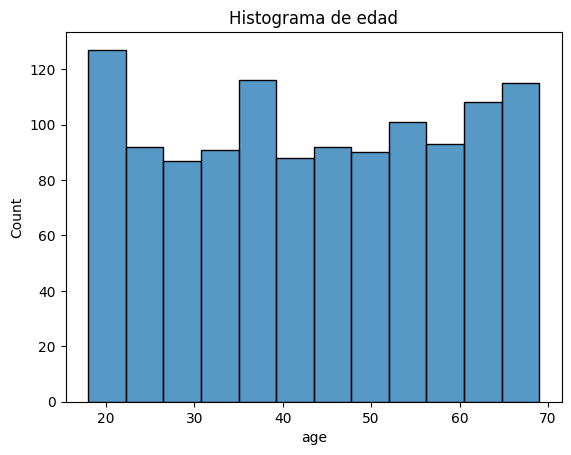

In [75]:
boxplot(df,'age','Edad')
histograma(df,'age','edad')

### Salario mensual

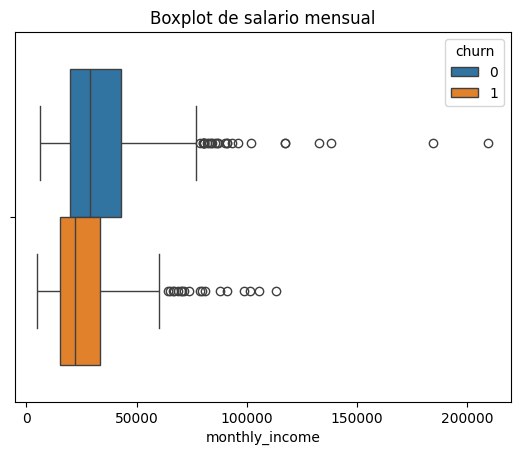

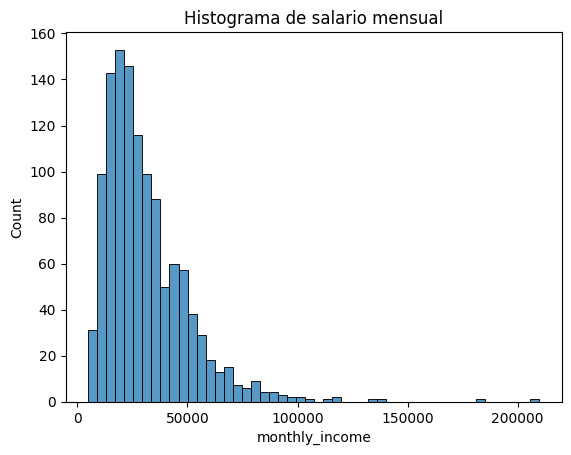

In [76]:
boxplot(df,'monthly_income', 'salario mensual','churn')
histograma(df,'monthly_income','salario mensual')

### factura mensual

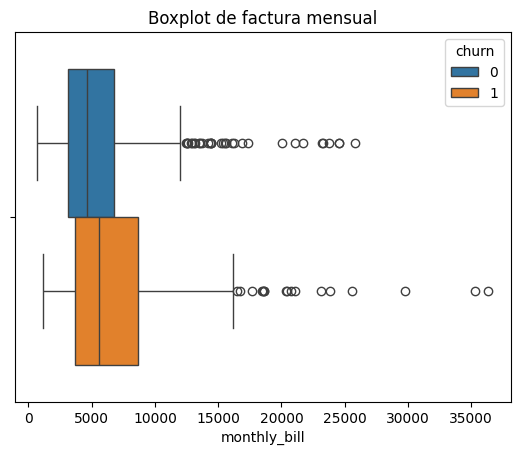

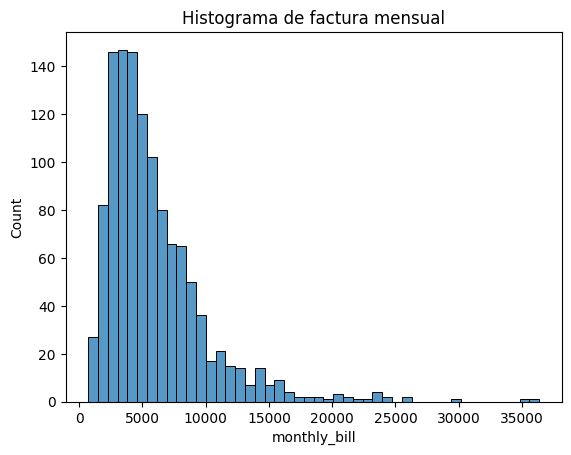

In [77]:
boxplot(df,'monthly_bill', 'factura mensual','churn')
histograma(df,'monthly_bill','factura mensual')

### Uso de internet

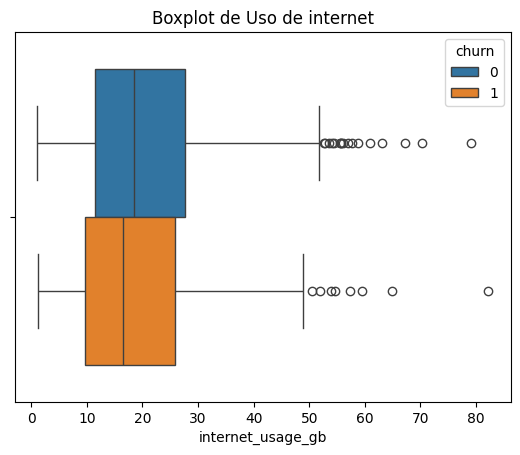

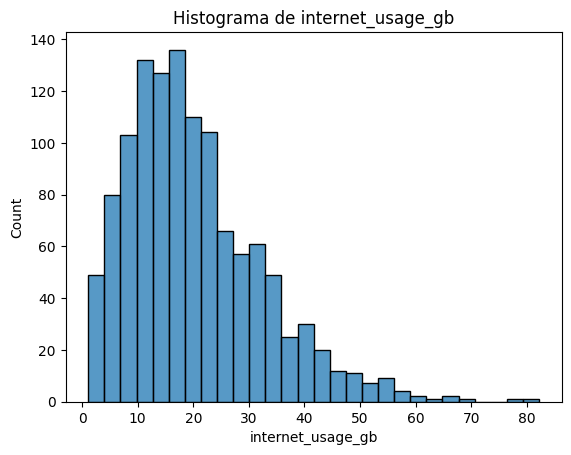

In [78]:
boxplot(df,'internet_usage_gb', 'Uso de internet','churn')
histograma(df,'internet_usage_gb','internet_usage_gb')

# ¿Cuales son las variables mas influyentes para que un cleinte deje el servicio?

## Ciudad

In [79]:
df['churn'].value_counts()

churn
0    780
1    420
Name: count, dtype: int64

In [80]:
# Asumo 0 como no abandono y 1 como abandono
df_churn = df[df['churn'] == 1]
df_churn.head()

,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
5,10006,2019-01-06,41,Female,Sialkot,Bachelor,Employed,36314.0,6663.0,23.8,88.0,Monthly,3,Customer support was helpful,1
16,10017,2019-01-17,57,Female,Karachi,Master,Employed,24972.0,12059.0,12.0,148.0,12-Month,2,Billing issues occurred multiple times,1
17,10018,2019-01-18,56,Male,Sialkot,Bachelor,Unemployed,17329.0,4597.0,27.5,257.0,Monthly,1,Satisfied with the service,1
19,10020,2019-01-20,66,Male,Faisalabad,Bachelor,Employed,17428.0,11195.0,18.6,146.0,Monthly,2,Happy with data packages,1
20,10021,2019-01-21,25,Male,Peshawar,Secondary,Employed,20382.0,3617.0,82.2,195.0,Monthly,2,Internet speed is very slow,1


In [81]:
df_churn['city'].value_counts().reset_index()   

,city,count
0,Lahore,44
1,Gujranwala,43
2,Quetta,42
3,Sialkot,41
4,Peshawar,41
5,Hyderabad,40
6,Rawalpindi,38
7,Islamabad,36
8,Multan,34
9,Karachi,32


In [82]:
df_nochurn = df[df['churn'] == 0]
df_nochurn['city'].value_counts().reset_index()

,city,count
0,Multan,79
1,Rawalpindi,78
2,Quetta,77
3,Faisalabad,74
4,Gujranwala,72
5,Sialkot,72
6,Karachi,68
7,Peshawar,67
8,Hyderabad,67
9,Lahore,64


In [83]:
tabla_city = pd.crosstab(df['city'], df['churn'], margins= True)
print(tabla_city)

churn         0    1   All
city                      
Faisalabad   74   29   103
Gujranwala   72   43   115
Hyderabad    67   40   107
Islamabad    62   36    98
Karachi      68   32   100
Lahore       64   44   108
Multan       79   34   113
Peshawar     67   41   108
Quetta       77   42   119
Rawalpindi   78   38   116
Sialkot      72   41   113
All         780  420  1200


In [84]:
chi2, p, dof, expected = chi2_contingency(tabla_city)

print("p-valor:", p)

p-valor: 0.9992589730984976


Como se puede apreciar la ciudad de la que mas abandonan el servicio es de Lahore, seguida de Gujranwala(aunque tambien es una de las que mas activa se encuentra, top 4), aunque esta variale no influyen en si alguien va abandonar el servicio

## Estado de empleo

In [85]:
df['employment_status'].value_counts()

employment_status
Employed         594
Self-Employed    226
Student          190
Unemployed       124
Retired           66
Name: count, dtype: int64

In [86]:
tabla = pd.crosstab(df['employment_status'], df['churn'], margins= True)
print(tabla)

churn                0    1   All
employment_status                
Employed           379  215   594
Retired             42   24    66
Self-Employed      158   68   226
Student            121   69   190
Unemployed          80   44   124
All                780  420  1200


In [87]:
tabla_porcetaje = pd.crosstab(df['employment_status'], df['churn'], normalize='index')*100
print(tabla_porcetaje)

churn                      0          1
employment_status                      
Employed           63.804714  36.195286
Retired            63.636364  36.363636
Self-Employed      69.911504  30.088496
Student            63.684211  36.315789
Unemployed         64.516129  35.483871


In [88]:
chi2, p, dof, expected = chi2_contingency(tabla)

print("p-valor:", p)

p-valor: 0.9818742285113671


Como se aprecia con la tabla y el propio chi² no hay una relacion entre las dos variables

## Salario mensual

In [89]:
df_limpio =borrar_outliers(df,'monthly_income')

Outliers encontrados: 40 (3.3%)


In [90]:
df_limpio.info()

<class 'pandas.DataFrame'>
Index: 1160 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1160 non-null   int64  
 1   signup_date        1160 non-null   str    
 2   age                1160 non-null   int64  
 3   gender             1160 non-null   str    
 4   city               1160 non-null   str    
 5   education_level    1160 non-null   str    
 6   employment_status  1160 non-null   str    
 7   monthly_income     1160 non-null   float64
 8   monthly_bill       1160 non-null   float64
 9   internet_usage_gb  1160 non-null   float64
 10  call_minutes       1160 non-null   float64
 11  contract_type      1160 non-null   str    
 12  support_tickets    1160 non-null   int64  
 13  customer_feedback  1160 non-null   str    
 14  churn              1160 non-null   int64  
dtypes: float64(4), int64(4), str(7)
memory usage: 145.0 KB


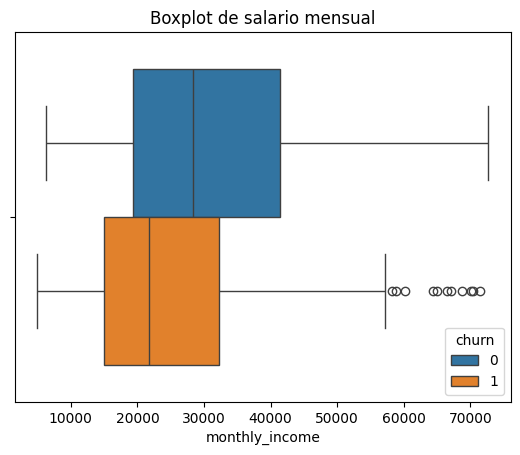

In [91]:
boxplot(df_limpio,'monthly_income', 'salario mensual','churn')

In [92]:
df_limpio.groupby('churn')['monthly_income'].agg(['mean','median','std'])

,mean,median,std
churn,,,
0,31017.680000,28325.0,14618.402166
1,25114.780488,21768.5,13647.476944


Aca si podemos ver que dejan el servicio posiblemente sea porque tienden a tener un salario un poco mas bajo, como  vemos en el boxplot y en la media y mediana de cada grupo que vemos que es mas baja de los que se retiran

### Minutos 

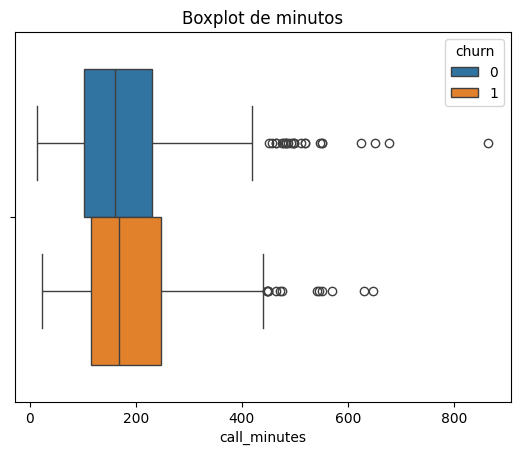

In [93]:
boxplot(df,'call_minutes', 'minutos','churn')

In [94]:
grupo_1 = df[df['churn'] == 1]['call_minutes']
grupo_0 = df[df['churn'] == 0]['call_minutes']
print(f'media del gupo 0: {grupo_0.mean()}, media del grupo 1: {grupo_1.mean()}')

media del gupo 0: 179.22948717948717, media del grupo 1: 189.51904761904763


In [95]:
print(f"Cohen_s d: {cohens_d(grupo_1, grupo_0)}")

Cohen_s d: 0.0961683690976429


En cuanto a los minutos no se ve una influencia clara en si estan cerca los datos y el coeficinete cohen's nos lo confirma al ser tan bajo el resultado

### Tipo de contrato

In [96]:
df['contract_type'].value_counts()

contract_type
Monthly     569
12-Month    345
6-Month     286
Name: count, dtype: int64

In [97]:
df.groupby('churn')['contract_type'].value_counts()

churn  contract_type
0      12-Month         284
       Monthly          273
       6-Month          223
1      Monthly          296
       6-Month           63
       12-Month          61
Name: count, dtype: int64

In [98]:
tabla = pd.crosstab(df['contract_type'], df['churn'], margins= True)
print(tabla)

churn            0    1   All
contract_type                
12-Month       284   61   345
6-Month        223   63   286
Monthly        273  296   569
All            780  420  1200


In [99]:
chi2, p, dof, expected = chi2_contingency(tabla)

print("p-valor:", p)

p-valor: 1.55091238663106e-27


Como vemos en la tabla de contingencia hay influencia entre el tipo de contrato y la permanencia del cliente, porque como vemos en planes de 6 meses en adelanta es muy poco el cliente que decide dejar le servicio, caso contrario en los que pagan mensualmente que si si hay un mayor numero de abandono.

Esta influencia nos la confirma el el chi² y el p-valor que es muy cercano a 0 

### Reseña

In [100]:
df['customer_feedback'].value_counts()  

customer_feedback
Satisfied with the service                 134
Coverage is poor in my location            132
Too expensive compared to competitors      130
Billing issues occurred multiple times     128
Customer support was helpful               119
Happy with data packages                   116
Internet speed is very slow                116
Service is unreliable during peak hours    116
Frequent call drops in my area             108
Network quality is good overall            101
Name: count, dtype: int64

In [101]:
tabla = pd.crosstab(df['customer_feedback'], df['churn'], margins= True)
print(tabla)

churn                                      0    1   All
customer_feedback                                      
Billing issues occurred multiple times    82   46   128
Coverage is poor in my location           87   45   132
Customer support was helpful              82   37   119
Frequent call drops in my area            72   36   108
Happy with data packages                  78   38   116
Internet speed is very slow               56   60   116
Network quality is good overall           65   36   101
Satisfied with the service                88   46   134
Service is unreliable during peak hours   80   36   116
Too expensive compared to competitors     90   40   130
All                                      780  420  1200


In [102]:
chi2, p, dof, expected = chi2_contingency(tabla)

print("p-valor:", p)

p-valor: 0.6258729908207108


En realidad en no hay una influencia real entre la reseña el churn por como vemos, apesar de que no hayan calificaciones tan buenas no es muy infuente en el abandono del servicio y el chi² cuadrado

# Conclusion 

Lo que mas enfluye en que un cliente siga tomando el servicio es el tipo de contrato que tiene con la compañia, por lo que sugiero que se trate de vender lo mejor posible los planes de mayores a 6 meses asi sea por medio de promociones o beneficios ya sea buscando escalar el plan o  desde el principio vender como servicio inicial esos planes, todo esto  con el fin de mantener el mayor numero de clientes.